In [25]:
import math
import matplotlib.pyplot as plt
import json
import math
from pathlib import Path
import math

In [4]:
def load_data(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data


def get_train_case(data, idx):
    assert "train" in data, "JSON must contain key 'train'"
    assert len(data["train"]) > 0, "train split is empty"
    return data["train"][idx]


json_path = "mw_dataset.json"
data = load_data(json_path)

print("Top-level keys:", list(data.keys()))
print("Config:", data["config"])
print("Number of train cases:", len(data["train"]))

case0 = get_train_case(data, 0)

print("\nFirst case keys:", list(case0.keys()))
print("n_steps:", case0["n_steps"])
print("learning_rate:", case0["learning_rate"])
print("len(expert_predictions):", len(case0["expert_predictions"]))
print("len(losses):", len(case0["losses"]))
print("len(true_labels):", len(case0["true_labels"]))
print("n_experts in first step:", len(case0["expert_predictions"][0]))

Top-level keys: ['config', 'train', 'val', 'test']
Config: {'n_train': 3000, 'n_val': 500, 'n_test': 200, 'max_steps': 50, 'n_experts': 4, 'seed': 42}
Number of train cases: 3000

First case keys: ['expert_predictions', 'losses', 'true_labels', 'n_steps', 'learning_rate']
n_steps: 41
learning_rate: 0.4084443440871048
len(expert_predictions): 41
len(losses): 41
len(true_labels): 41
n_experts in first step: 4


In [5]:
def validate_case(case):
    n_steps = case["n_steps"]
    n_experts = len(case["expert_predictions"][0])

    assert len(case["expert_predictions"]) == n_steps, "expert_predictions length != n_steps"
    assert len(case["losses"]) == n_steps, "losses length != n_steps"
    assert len(case["true_labels"]) == n_steps, "true_labels length != n_steps"

    for t in range(n_steps):
        assert len(case["expert_predictions"][t]) == n_experts, f"expert_predictions[{t}] length mismatch"
        assert len(case["losses"][t]) == n_experts, f"losses[{t}] length mismatch"

    print("Case is valid.")
    print("n_steps =", n_steps)
    print("n_experts =", n_experts)



In [6]:
def get_expert_error_rates(case):
    """
    Input:
        case: a dict like case0, containing
            - "expert_predictions": list of length n_steps, each item is a list of length n_experts
            - "true_labels": list of length n_steps

    Output:
        A dict with:
            - "error_counts": list of length n_experts
            - "error_rates": list of length n_experts
            - "n_steps": int
            - "n_experts": int
    """
    expert_predictions = case["expert_predictions"]
    true_labels = case["true_labels"]
    n_steps = case["n_steps"]

    assert len(expert_predictions) == n_steps, "expert_predictions length != n_steps"
    assert len(true_labels) == n_steps, "true_labels length != n_steps"

    n_experts = len(expert_predictions[0])
    error_counts = [0] * n_experts

    for t in range(n_steps):
        assert len(expert_predictions[t]) == n_experts, f"Step {t} has wrong number of experts"
        y = true_labels[t]
        for i in range(n_experts):
            if expert_predictions[t][i] != y:
                error_counts[i] += 1

    error_rates = [cnt / n_steps for cnt in error_counts]

    return {
        "error_counts": error_counts,
        "error_rates": error_rates,
        "n_steps": n_steps,
        "n_experts": n_experts,
    }

In [7]:
def normalize(weights):
    s = sum(weights)
    assert s > 0, "sum of weights must be positive"
    return [w / s for w in weights]


def run_multiplicative_weights(case):
    losses = case["losses"]
    eta = case["learning_rate"]
    n_steps = case["n_steps"]
    n_experts = len(losses[0])

    # initial uniform weights
    w = [1.0 / n_experts] * n_experts
    weights_sequence = [w.copy()]   # include initial weights

    for t in range(n_steps):
        new_w = []
        for i in range(n_experts):
            updated = w[i] * math.exp(-eta * losses[t][i])
            new_w.append(updated)
        w = normalize(new_w)
        weights_sequence.append(w.copy())

    return weights_sequence


mw_weights_case0 = run_multiplicative_weights(case0)

print("Length of output weights_sequence:", len(mw_weights_case0))
print("Initial weights:", mw_weights_case0[0])
print("Weights after first step:", mw_weights_case0[1])
print("Weights after second step:", mw_weights_case0[2])

Length of output weights_sequence: 42
Initial weights: [0.25, 0.25, 0.25, 0.25]
Weights after first step: [0.3003574015747564, 0.19964259842524362, 0.3003574015747564, 0.19964259842524362]
Weights after second step: [0.3339957141813077, 0.22200142860623073, 0.22200142860623073, 0.22200142860623073]


In [8]:
def plot_expert_weights(case):
    weights_sequence = run_multiplicative_weights(case)
    n_experts = len(weights_sequence[0])
    steps = list(range(len(weights_sequence)))  # 0,1,...,n_steps

    colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]

    plt.figure(figsize=(9, 5))
    for i in range(n_experts):
        ys = [w[i] for w in weights_sequence]
        plt.plot(
            steps,
            ys,
            label=f"Expert {i}",
            linewidth=2.5,
            color=colors[i]
        )

    plt.xlabel("Step")
    plt.ylabel("Weight")
    plt.title("Multiplicative Weights over Time")
    plt.xticks(steps if len(steps) <= 20 else None)
    plt.ylim(0, 1)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [9]:
def compute_regret_curve(case):
    """
    Returns:
      steps: [1, 2, ..., n_steps]
      regret_curve[t-1] = cumulative regret up to step t
      alg_cum_losses[t-1] = cumulative algorithm loss up to step t
      best_expert_cum_losses[t-1] = cumulative loss of best fixed expert up to step t
      expert_cum_losses: list of per-expert cumulative loss curves
    """
    losses = case["losses"]
    n_steps = case["n_steps"]
    n_experts = len(losses[0])

    weights_sequence = run_multiplicative_weights(case)

    alg_cum = 0.0
    expert_cum = [0.0] * n_experts

    alg_cum_losses = []
    best_expert_cum_losses = []
    regret_curve = []
    expert_cum_losses = [[] for _ in range(n_experts)]

    for t in range(n_steps):
        w_t = weights_sequence[t]   # use w_t on loss at step t
        l_t = losses[t]

        alg_loss_t = sum(w_t[i] * l_t[i] for i in range(n_experts))
        alg_cum += alg_loss_t

        for i in range(n_experts):
            expert_cum[i] += l_t[i]
            expert_cum_losses[i].append(expert_cum[i])

        best_expert_cum = min(expert_cum)
        regret = alg_cum - best_expert_cum

        alg_cum_losses.append(alg_cum)
        best_expert_cum_losses.append(best_expert_cum)
        regret_curve.append(regret)

    steps = list(range(1, n_steps + 1))
    return {
        "steps": steps,
        "regret_curve": regret_curve,
        "alg_cum_losses": alg_cum_losses,
        "best_expert_cum_losses": best_expert_cum_losses,
        "expert_cum_losses": expert_cum_losses,
    }

In [10]:
# regret plot
def plot_regret_curve(case):
    stats = compute_regret_curve(case)
    steps = stats["steps"]
    regret_curve = stats["regret_curve"]
    avg_regret_curve = [r / t for r, t in zip(regret_curve, steps)]

    fig, ax1 = plt.subplots(figsize=(9, 5))

    color1 = "#7A3E9D"
    color2 = "#4C78A8"

    line1 = ax1.plot(
        steps,
        regret_curve,
        linewidth=2.5,
        color=color1,
        label="Cumulative regret"
    )
    ax1.set_xlabel("Step")
    ax1.set_ylabel("Cumulative Regret", color=color1)
    ax1.tick_params(axis="y", labelcolor=color1)
    ax1.grid(alpha=0.25)

    ax2 = ax1.twinx()
    line2 = ax2.plot(
        steps,
        avg_regret_curve,
        linewidth=2.5,
        color=color2,
        label="Average regret"
    )
    ax2.set_ylabel("Average Regret", color=color2)
    ax2.tick_params(axis="y", labelcolor=color2)

    lines = line1 + line2
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="upper right")

    plt.title("Cumulative and Average Regret")
    plt.tight_layout()
    plt.show()

In [11]:
def plot_algorithm_vs_best_expert(case):
    stats = compute_regret_curve(case)
    steps = stats["steps"]

    plt.figure(figsize=(9, 5))
    plt.plot(
        steps,
        stats["alg_cum_losses"],
        linewidth=2.5,
        color="#4C78A8",
        label="Algorithm cumulative loss"
    )
    plt.plot(
        steps,
        stats["best_expert_cum_losses"],
        linewidth=2.5,
        color="#E45756",
        label="Best expert cumulative loss"
    )

    plt.xlabel("Step")
    plt.ylabel("Cumulative Loss")
    plt.title("Algorithm vs Best Expert")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


You are given one sequential expert-prediction instance with n experts and T time steps.

Definitions:
- expert_predictions[t][i] is the binary prediction of expert i at step t.
- true_labels[t] is the true binary label at step t.
- losses[t][i] is the 0-1 loss of expert i at step t:
  losses[t][i] = 0 if expert_predictions[t][i] = true_labels[t], and 1 otherwise.
- eta is the learning rate.

Initialize the expert weights uniformly:
w_0[i] = 1/n for all i.

For each step t = 0, 1, ..., T-1:
1. Compute the mixture probability
   q_t = sum_i w_t[i] * expert_predictions[t][i].
2. Compute the algorithm's binary prediction:
   yhat_t = 1 if q_t >= 0.5, and 0 otherwise.
3. Update the expert weights by multiplicative weights:
   w_{t+1}[i] ∝ w_t[i] * exp(-eta * losses[t][i]),
   followed by normalization so that the weights sum to 1.

Task:
Compute
- the full weight sequence w_0, w_1, ..., w_T,
- the mixture probability q_t at each step,
- the binary algorithm prediction yhat_t at each step.

Important requirements:
- Do not use any external tools.
- Do not write or execute code.
- Do not provide any reasoning steps or intermediate calculations.
- Output valid JSON only.

Required output format:
{
  "weights_sequence": [[...], [...], ...],
  "mixture_probabilities": [...],
  "algorithm_predictions": [...]
}

Input:
{
  "n": 4,
  "T": 5,
  "eta": 0.4,
  "expert_predictions": [
    [0, 1, 0, 1],
    [1, 1, 0, 1],
    [1, 1, 1, 1],
    [1, 0, 0, 1],
    [1, 1, 0, 0]
  ],
  "true_labels": [0, 1, 1, 0, 0]
}

In [12]:
DEFAULT_PROMPT_TEMPLATE = """You are given one sequential expert-prediction instance with n experts and T time steps.

Definitions:
- expert_predictions[t][i] is the binary prediction of expert i at step t.
- true_labels[t] is the true binary label at step t.
- losses[t][i] is the 0-1 loss of expert i at step t:
  losses[t][i] = 0 if expert_predictions[t][i] = true_labels[t], and 1 otherwise.
- eta is the learning rate.

Initialize the expert weights uniformly:
w_0[i] = 1/n for all i.

For each step t = 0, 1, ..., T-1:
1. Compute the mixture probability
   q_t = sum_i w_t[i] * expert_predictions[t][i].
2. Compute the algorithm's binary prediction:
   yhat_t = 1 if q_t >= 0.5, and 0 otherwise.
3. Update the expert weights by multiplicative weights:
   w_{{t+1}}[i] ∝ w_t[i] * exp(-eta * losses[t][i]),
   followed by normalization so that the weights sum to 1.

Task:
Compute
- the full weight sequence w_0, w_1, ..., w_T,
- the mixture probability q_t at each step,
- the binary algorithm prediction yhat_t at each step.

Important requirements:
- Do not use any external tools.
- Do not write or execute code.
- Do not provide any reasoning steps or intermediate calculations.
- Output valid JSON only.

Required output format:
{{
  "weights_sequence": [[...], [...], ...],
  "mixture_probabilities": [...],
  "algorithm_predictions": [...]
}}

Input:
{input_json}
"""


In [13]:
def check_weight_normalization(model_output, tol=1e-6):
    """
    Check that every weight vector in model_output["weights_sequence"] sums to 1.

    Returns a dict with:
      "all_normalized": bool
      "bad_steps": list of (step_index, actual_sum) for steps that fail
      "max_deviation": float
    """
    weights_sequence = model_output["weights_sequence"]
    bad_steps = []
    max_dev = 0.0

    for t, w in enumerate(weights_sequence):
        s = sum(w)
        dev = abs(s - 1.0)
        max_dev = max(max_dev, dev)
        if dev > tol:
            bad_steps.append((t, s))

    return {
        "all_normalized": len(bad_steps) == 0,
        "bad_steps": bad_steps,
        "max_deviation": max_dev,
    }


In [14]:
def build_mw_prompt(case, prompt_template=DEFAULT_PROMPT_TEMPLATE, include_losses=False):
    """
    Build a prompt string from one case.

    Inputs:
      case: one dataset case
      prompt_template: string template containing {input_json}
      include_losses: whether to include losses in the input JSON

    Returns:
      prompt string
    """
    n_experts = len(case["expert_predictions"][0])

    input_dict = {
        "n": n_experts,
        "T": case["n_steps"],
        "eta": case["learning_rate"],
        "expert_predictions": case["expert_predictions"],
        "true_labels": case["true_labels"],
    }

    if include_losses:
        input_dict["losses"] = case["losses"]

    input_json = json.dumps(input_dict, indent=2)

    prompt = prompt_template.format(input_json=input_json)
    return prompt

In [15]:
def get_ground_truth_outputs(case):
    """
    Returns ground-truth:
      - weights_sequence: length T+1
      - mixture_probabilities: length T
      - algorithm_predictions: length T
    """
    expert_predictions = case["expert_predictions"]
    n_steps = case["n_steps"]
    n_experts = len(expert_predictions[0])

    weights_sequence = run_multiplicative_weights(case)

    mixture_probabilities = []
    algorithm_predictions = []

    for t in range(n_steps):
        w_t = weights_sequence[t]
        preds_t = expert_predictions[t]

        q_t = sum(w_t[i] * preds_t[i] for i in range(n_experts))
        yhat_t = 1 if q_t >= 0.5 else 0

        mixture_probabilities.append(q_t)
        algorithm_predictions.append(yhat_t)

    return {
        "weights_sequence": weights_sequence,
        "mixture_probabilities": mixture_probabilities,
        "algorithm_predictions": algorithm_predictions,
    }

In [16]:
def analyze_model_output(case, model_output, prob_tol=1e-3, weight_tol=1e-3):
    """
    Analyze one model output against ground truth.

    Inputs:
      case: one case dict
      model_output: dict or JSON string with keys
          - weights_sequence
          - mixture_probabilities
          - algorithm_predictions

    Returns:
      summary dict
    """
    if isinstance(model_output, str):
        model_output = json.loads(model_output)

    gt = get_ground_truth_outputs(case)

    summary = {
        "format_ok": True,
        "messages": [],
    }

    required_keys = ["weights_sequence", "mixture_probabilities", "algorithm_predictions"]
    for key in required_keys:
        if key not in model_output:
            summary["format_ok"] = False
            summary["messages"].append(f"Missing key: {key}")

    if not summary["format_ok"]:
        return summary

    pred_weights = model_output["weights_sequence"]
    pred_probs = model_output["mixture_probabilities"]
    pred_preds = model_output["algorithm_predictions"]

    true_weights = gt["weights_sequence"]
    true_probs = gt["mixture_probabilities"]
    true_preds = gt["algorithm_predictions"]

    # length checks
    expected_weight_len = len(true_weights)
    expected_prob_len = len(true_probs)
    expected_pred_len = len(true_preds)

    summary["length_checks"] = {
        "weights_sequence": (len(pred_weights), expected_weight_len),
        "mixture_probabilities": (len(pred_probs), expected_prob_len),
        "algorithm_predictions": (len(pred_preds), expected_pred_len),
    }

    if len(pred_weights) != expected_weight_len:
        summary["messages"].append(
            f"weights_sequence length mismatch: got {len(pred_weights)}, expected {expected_weight_len}"
        )
    if len(pred_probs) != expected_prob_len:
        summary["messages"].append(
            f"mixture_probabilities length mismatch: got {len(pred_probs)}, expected {expected_prob_len}"
        )
    if len(pred_preds) != expected_pred_len:
        summary["messages"].append(
            f"algorithm_predictions length mismatch: got {len(pred_preds)}, expected {expected_pred_len}"
        )

    # Compare only up to common length, to avoid crashing
    T_w = min(len(pred_weights), len(true_weights))
    T_p = min(len(pred_probs), len(true_probs))
    T_y = min(len(pred_preds), len(true_preds))

    # weights error
    max_weight_abs_err = 0.0
    mean_weight_abs_err = 0.0
    weight_count = 0
    bad_weight_steps = []

    for t in range(T_w):
        if len(pred_weights[t]) != len(true_weights[t]):
            summary["messages"].append(
                f"weights_sequence[{t}] dimension mismatch: got {len(pred_weights[t])}, expected {len(true_weights[t])}"
            )
            continue

        row_max_err = 0.0
        for a, b in zip(pred_weights[t], true_weights[t]):
            err = abs(a - b)
            row_max_err = max(row_max_err, err)
            max_weight_abs_err = max(max_weight_abs_err, err)
            mean_weight_abs_err += err
            weight_count += 1

        if row_max_err > weight_tol:
            bad_weight_steps.append((t, row_max_err))

    mean_weight_abs_err = mean_weight_abs_err / weight_count if weight_count > 0 else None

    # probability error
    max_prob_abs_err = 0.0
    mean_prob_abs_err = 0.0
    bad_prob_steps = []

    for t in range(T_p):
        err = abs(pred_probs[t] - true_probs[t])
        max_prob_abs_err = max(max_prob_abs_err, err)
        mean_prob_abs_err += err
        if err > prob_tol:
            bad_prob_steps.append((t, err, pred_probs[t], true_probs[t]))

    mean_prob_abs_err = mean_prob_abs_err / T_p if T_p > 0 else None

    # prediction accuracy
    pred_match_count = 0
    bad_pred_steps = []

    for t in range(T_y):
        if pred_preds[t] == true_preds[t]:
            pred_match_count += 1
        else:
            bad_pred_steps.append((t, pred_preds[t], true_preds[t]))

    pred_accuracy = pred_match_count / T_y if T_y > 0 else None

    # exact-ish checks
    weights_all_close = (max_weight_abs_err <= weight_tol)
    probs_all_close = (max_prob_abs_err <= prob_tol)
    preds_all_correct = (pred_accuracy == 1.0)

    summary.update({
        "weights": {
            "max_abs_error": max_weight_abs_err,
            "mean_abs_error": mean_weight_abs_err,
            "all_close": weights_all_close,
            "bad_steps": bad_weight_steps[:10],
        },
        "mixture_probabilities": {
            "max_abs_error": max_prob_abs_err,
            "mean_abs_error": mean_prob_abs_err,
            "all_close": probs_all_close,
            "bad_steps": bad_prob_steps[:10],
        },
        "algorithm_predictions": {
            "accuracy": pred_accuracy,
            "all_correct": preds_all_correct,
            "bad_steps": bad_pred_steps[:10],
        },
        "overall": {
            "weights_ok": weights_all_close,
            "probabilities_ok": probs_all_close,
            "predictions_ok": preds_all_correct,
        }
    })

    return summary

In [17]:
def compute_regret_curve_from_weights(case, weights_sequence):
    """
    Compute regret curve using a provided weights_sequence.

    Inputs:
      case: one dataset case
      weights_sequence: list of length n_steps + 1, where weights_sequence[t] = w_t

    Returns:
      {
        "steps": [1, 2, ..., n_steps],
        "regret_curve": cumulative regret up to each step,
        "alg_cum_losses": cumulative algorithm loss,
        "best_expert_cum_losses": cumulative loss of best expert up to each step,
        "expert_cum_losses": per-expert cumulative loss curves
      }
    """
    losses = case["losses"]
    n_steps = case["n_steps"]
    n_experts = len(losses[0])

    assert len(weights_sequence) == n_steps + 1, (
        f"weights_sequence should have length {n_steps + 1}, got {len(weights_sequence)}"
    )

    alg_cum = 0.0
    expert_cum = [0.0] * n_experts

    alg_cum_losses = []
    best_expert_cum_losses = []
    regret_curve = []
    expert_cum_losses = [[] for _ in range(n_experts)]

    for t in range(n_steps):
        w_t = weights_sequence[t]
        l_t = losses[t]

        assert len(w_t) == n_experts, (
            f"weights_sequence[{t}] should have length {n_experts}, got {len(w_t)}"
        )

        alg_loss_t = sum(w_t[i] * l_t[i] for i in range(n_experts))
        alg_cum += alg_loss_t

        for i in range(n_experts):
            expert_cum[i] += l_t[i]
            expert_cum_losses[i].append(expert_cum[i])

        best_expert_cum = min(expert_cum)
        regret = alg_cum - best_expert_cum

        alg_cum_losses.append(alg_cum)
        best_expert_cum_losses.append(best_expert_cum)
        regret_curve.append(regret)

    steps = list(range(1, n_steps + 1))
    return {
        "steps": steps,
        "regret_curve": regret_curve,
        "alg_cum_losses": alg_cum_losses,
        "best_expert_cum_losses": best_expert_cum_losses,
        "expert_cum_losses": expert_cum_losses,
    }

In [18]:
def plot_regret_comparison(case, model_output):
    """
    Plot cumulative regret and average regret:
    true MW vs model MW
    """
    true_stats = compute_regret_curve(case)
    model_stats = compute_regret_curve_from_weights(case, model_output["weights_sequence"])

    steps = true_stats["steps"]

    true_regret = true_stats["regret_curve"]
    model_regret = model_stats["regret_curve"]

    true_avg_regret = [r / t for r, t in zip(true_regret, steps)]
    model_avg_regret = [r / t for r, t in zip(model_regret, steps)]

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # left axis: cumulative regret
    l1 = ax1.plot(
        steps, true_regret,
        linewidth=2.5, color="#7A3E9D",
        label="True MW cumulative regret"
    )
    l2 = ax1.plot(
        steps, model_regret,
        linewidth=2.5, color="#C17CEB", linestyle="--",
        label="Model cumulative regret"
    )
    ax1.set_xlabel("Step")
    ax1.set_ylabel("Cumulative Regret")
    ax1.grid(alpha=0.25)

    # right axis: average regret
    ax2 = ax1.twinx()
    l3 = ax2.plot(
        steps, true_avg_regret,
        linewidth=2.5, color="#4C78A8",
        label="True MW average regret"
    )
    l4 = ax2.plot(
        steps, model_avg_regret,
        linewidth=2.5, color="#72B7F2", linestyle="--",
        label="Model average regret"
    )
    ax2.set_ylabel("Average Regret")

    lines = l1 + l2 + l3 + l4
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="upper right")

    plt.title("Regret Comparison: True MW vs Model MW")
    plt.tight_layout()
    plt.show()

In [19]:
def plot_weight_comparison(case, model_output):
    """
    Plot expert weights over time:
    true MW vs model MW
    """
    true_weights = run_multiplicative_weights(case)
    model_weights = model_output["weights_sequence"]

    n_steps = case["n_steps"]
    n_experts = len(case["losses"][0])

    assert len(model_weights) == n_steps + 1, (
        f"model weights_sequence should have length {n_steps + 1}, got {len(model_weights)}"
    )

    steps = list(range(n_steps + 1))
    colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]

    plt.figure(figsize=(10, 6))

    for i in range(n_experts):
        true_y = [true_weights[t][i] for t in range(n_steps + 1)]
        model_y = [model_weights[t][i] for t in range(n_steps + 1)]

        plt.plot(
            steps,
            true_y,
            linewidth=2.5,
            color=colors[i],
            label=f"Expert {i} true"
        )
        plt.plot(
            steps,
            model_y,
            linewidth=2.5,
            color=colors[i],
            linestyle="--",
            label=f"Expert {i} model"
        )

    plt.xlabel("Step")
    plt.ylabel("Weight")
    plt.title("Weight Comparison: True MW vs Model MW")
    plt.ylim(0, 1)
    plt.grid(alpha=0.25)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

In [20]:
# ── GENERATE PROMPT ──────────────────────────────────────────────────────────
# Pick any split ("train", "val", "test") and index, then copy the printed
# prompt into the LLM of your choice.

SPLIT = "train"   # "train" | "val" | "test"
CASE_IDX = 0      # which case to test

data = load_data("mw_dataset.json")
case = data[SPLIT][CASE_IDX]

validate_case(case)
prompt = build_mw_prompt(case)
print(prompt)


Case is valid.
n_steps = 41
n_experts = 4
You are given one sequential expert-prediction instance with n experts and T time steps.

Definitions:
- expert_predictions[t][i] is the binary prediction of expert i at step t.
- true_labels[t] is the true binary label at step t.
- losses[t][i] is the 0-1 loss of expert i at step t:
  losses[t][i] = 0 if expert_predictions[t][i] = true_labels[t], and 1 otherwise.
- eta is the learning rate.

Initialize the expert weights uniformly:
w_0[i] = 1/n for all i.

For each step t = 0, 1, ..., T-1:
1. Compute the mixture probability
   q_t = sum_i w_t[i] * expert_predictions[t][i].
2. Compute the algorithm's binary prediction:
   yhat_t = 1 if q_t >= 0.5, and 0 otherwise.
3. Update the expert weights by multiplicative weights:
   w_{t+1}[i] ∝ w_t[i] * exp(-eta * losses[t][i]),
   followed by normalization so that the weights sum to 1.

Task:
Compute
- the full weight sequence w_0, w_1, ..., w_T,
- the mixture probability q_t at each step,
- the binary 

=== Weight Normalization ===
All normalized: True
Max deviation from 1.0: 1.000000082740371e-09

=== Correctness Analysis ===
{'algorithm_predictions': {'accuracy': 0.8292682926829268,
                           'all_correct': False,
                           'bad_steps': [(4, 0, 1),
                                         (14, 1, 0),
                                         (16, 1, 0),
                                         (17, 0, 1),
                                         (18, 1, 0),
                                         (31, 0, 1),
                                         (38, 1, 0)]},
 'format_ok': True,
 'length_checks': {'algorithm_predictions': (41, 41),
                   'mixture_probabilities': (41, 41),
                   'weights_sequence': (42, 42)},
 'messages': [],
 'mixture_probabilities': {'all_close': False,
                           'bad_steps': [(1,
                                          0.022579623796978532,
                                          0

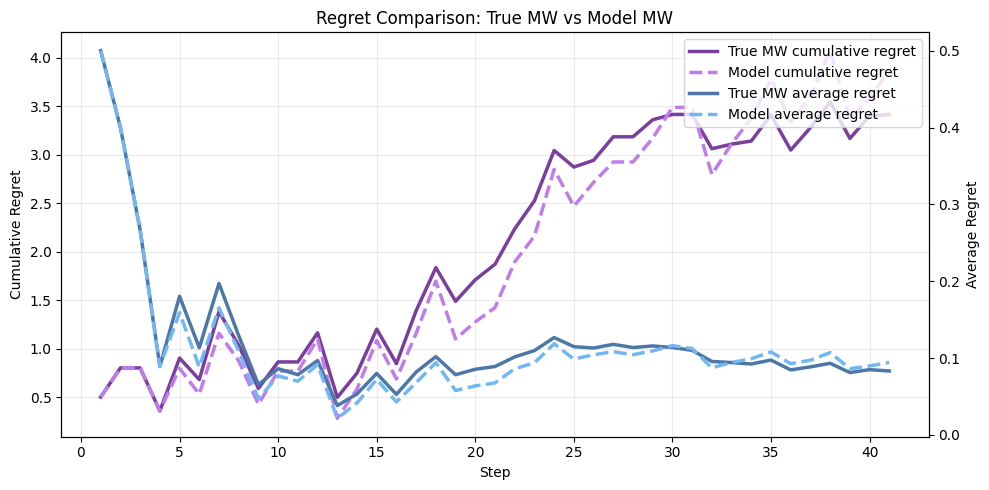

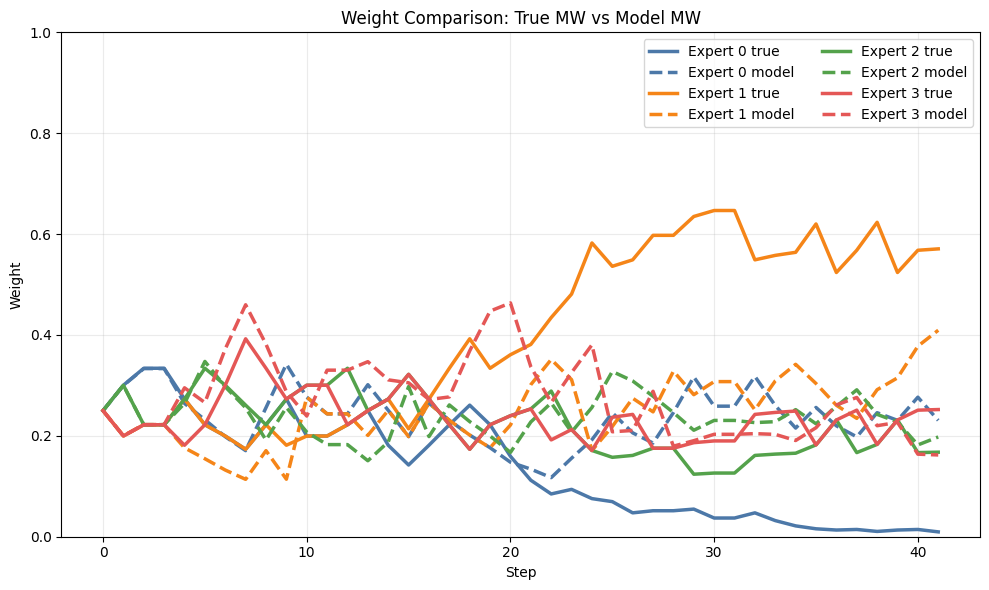

In [23]:
# ── EVALUATE MODEL OUTPUT ────────────────────────────────────────────────────
# Paste the raw JSON the model returned between the triple-quotes below,
# then run this cell.

MODEL_OUTPUT_JSON = """
{
  "weights_sequence": [
    [0.25, 0.25, 0.25, 0.25],
    [0.3, 0.2, 0.3, 0.2],
    [0.3333333333333333, 0.2222222222222222, 0.2222222222222222, 0.2222222222222222],
    [0.3333333333333333, 0.2222222222222222, 0.2222222222222222, 0.2222222222222222],
    [0.2642898715886477, 0.17619324772576512, 0.2642898715886477, 0.2952270090969395],
    [0.23190471239999464, 0.15460314159999642, 0.3475151528657685, 0.26597699313424046],
    [0.1983083168862916, 0.13220554459086105, 0.2971230191244458, 0.37236311940000004],
    [0.1706684704514867, 0.11377898030099112, 0.2557116523910543, 0.4598408968564679],
    [0.2559381745747683, 0.1706254497165122, 0.19176378413693254, 0.381672591571787],
    [0.3421312384918712, 0.11404374616395707, 0.2563172559021484, 0.28750775944202334],
    [0.27666276856627725, 0.27666276856627725, 0.2074328812678631, 0.23924158159958245],
    [0.24357754602288147, 0.24357754602288147, 0.1826261543883017, 0.33021875356593537],
    [0.24357754602288147, 0.24357754602288147, 0.1826261543883017, 0.33021875356593537],
    [0.3013770335031124, 0.20091802233540825, 0.15064215283921876, 0.3470627913222606],
    [0.2505677054941913, 0.2505677054941913, 0.18786315516904627, 0.3110014338425712],
    [0.19853900227280387, 0.19853900227280387, 0.2977114757319983, 0.30521051972239396],
    [0.2647738012627945, 0.2647738012627945, 0.1985160867865201, 0.27193631068789094],
    [0.2307844093959146, 0.2307844093959146, 0.2612769430396956, 0.2771542381684752],
    [0.20158409746324682, 0.20158409746324682, 0.22822030238032737, 0.368611502693179],
    [0.17646142730623696, 0.17646142730623696, 0.19977085189312155, 0.4473062934944046],
    [0.1477176449089947, 0.2215039203649642, 0.1672323719266661, 0.46354606279937504],
    [0.13401761622353086, 0.3014524193361138, 0.22754655455209765, 0.3369834098882576],
    [0.11718174542289196, 0.3514285942363155, 0.26526132049007425, 0.26612834035071833],
    [0.15570258056298515, 0.3114051611259703, 0.2075355030467771, 0.32535675526426743],
    [0.19232877395048598, 0.1709195156220392, 0.2562947262075935, 0.3804569842198813],
    [0.24584732168345714, 0.21847625076479008, 0.3276092015091728, 0.20806722604257997],
    [0.2059345511306352, 0.27457940150751357, 0.3088188151525985, 0.2106672322092527],
    [0.18567252251012356, 0.24756336334683144, 0.2784348507304217, 0.28832926341262334],
    [0.24614614488967963, 0.32819485985290615, 0.24614614488967963, 0.17951285036773463],
    [0.3168694065600762, 0.2815928815234237, 0.21113076595213697, 0.19040694596436322],
    [0.25883214870425026, 0.30752763297157834, 0.23058092264624738, 0.20305929567792403],
    [0.25883214870425026, 0.30752763297157834, 0.23058092264624738, 0.20305929567792403],
    [0.3179261314999557, 0.2514686440615179, 0.22625292534898144, 0.20435229908954495],
    [0.26002927236592284, 0.308945899268686, 0.22810842777174624, 0.20291639959364488],
    [0.2154406517604675, 0.341818131376378, 0.2519504746355416, 0.19079074222761295],
    [0.25624765992926715, 0.3037234857731765, 0.2239331828859942, 0.2160956714115622],
    [0.21987513364230282, 0.2606132415177897, 0.2582875153284758, 0.26122410951143167],
    [0.19799296564619464, 0.2346746813876935, 0.2912440306170668, 0.27608832234904514],
    [0.24588820422171172, 0.2914407865664327, 0.24258907310574892, 0.22008193610610665],
    [0.23067162608249622, 0.314955767795325, 0.22757692795859187, 0.22679567816358688],
    [0.2766324901533257, 0.3777114671449419, 0.18197771720499684, 0.1636783254967356],
    [0.23071337199484085, 0.4093959146580415, 0.1977651036069796, 0.16212560974013803]
  ],
  "mixture_probabilities": [
    0.5,
    0.7222222222222222,
    1.0,
    0.6289168806852729,
    0.3865078539999911,
    0.26597699313424046,
    0.37236311940000004,
    0.7155525492475222,
    0.44770195871169083,
    0.6578687615081288,
    0,
    0.6697812464340646,
    0.1826261543883017,
    0.6986229664968875,
    0.5011354109883827,
    0.6029219954543922,
    0.529547602525589,
    0.4615688187918292,
    0.5968318050735063,
    0.823538572693763,
    0.1477176449089947,
    0.47100102611178846,
    0.26526132049007425,
    0.3114051611259703,
    0.3804569842198813,
    0.75415277395742,
    0.7893327677907472,
    0,
    0.24614614488967963,
    0.6831305934399238,
    1.0,
    0.30752763297157834,
    0.7401374526065263,
    0.7399707276340772,
    0.40623139398808044,
    0.5599711457024436,
    0.741712484671524,
    0.4740812879952398,
    0.7085592134335672,
    0.22757692795859187,
    0.7233675098466743
  ],
  "algorithm_predictions": [
    1,
    1,
    1,
    1,
    0,
    0,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    1,
    1,
    1,
    0,
    1,
    1,
    0,
    0,
    0,
    0,
    0,
    1,
    1,
    0,
    0,
    1,
    1,
    0,
    1,
    1,
    0,
    1,
    1,
    0,
    1,
    0,
    1
  ]
}
"""

model_output = json.loads(MODEL_OUTPUT_JSON)

# 1. Normalization check
norm = check_weight_normalization(model_output)
print("=== Weight Normalization ===")
print("All normalized:", norm["all_normalized"])
print("Max deviation from 1.0:", norm["max_deviation"])
if norm["bad_steps"]:
    print("Bad steps (step, sum):", norm["bad_steps"][:10])

# 2. Correctness analysis vs ground truth
print()
print("=== Correctness Analysis ===")
summary = analyze_model_output(case, model_output)
import pprint
pprint.pprint(summary)

# 3. Plots
plot_regret_comparison(case, model_output)
plot_weight_comparison(case, model_output)
